# Hand Hygiene Detection — UV Dataset
### YOLOv8 Object Detection: Clean vs Dirty vs Partial Hand Classification

This notebook walks through the **complete pipeline** for training a YOLOv8 object detection model
on the hand-hygiene UV dataset, step by step:

1. Environment setup & dependency installation
2. Importing libraries
3. Checking GPU availability
4. Exploring the dataset structure
5. Visualizing sample images with annotations
6. Configuring the dataset YAML
7. Training the YOLOv8 model
8. Reviewing training results & metrics
9. Validating the model
10. Running inference on test images
11. Exporting the final model

**Classes:** `clean`, `dirty`, `partial`


## 1. Install Dependencies

We use the `ultralytics` package, which provides the YOLOv8 implementation, along with
supporting libraries for visualization.


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Install ultralytics (YOLOv8) and other requirements
# Run this once — comment out after the first successful run
!pip install ultralytics opencv-python matplotlib pandas --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.1 MB/s eta 0:00:00


In [10]:
# ---- SINGLE SOURCE OF TRUTH FOR ALL PATHS ----
dataset_root = "/content/drive/MyDrive/HandCleaner.v2i.yolov8"
data_yaml_path = os.path.join(dataset_root, "data.yaml")

print("dataset_root:", dataset_root)
print("data_yaml_path:", data_yaml_path)

dataset_root: /content/drive/MyDrive/HandCleaner.v2i.yolov8
data_yaml_path: /content/drive/MyDrive/HandCleaner.v2i.yolov8/data.yaml


## 2. Import Libraries


In [11]:
import os
import glob
import yaml
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from pathlib import Path

from ultralytics import YOLO
import torch

print("Ultralytics + Torch imported successfully")


Ultralytics + Torch imported successfully


## 3. Check GPU Availability

Training on GPU (`cuda`) is significantly faster than CPU. This confirms whether PyTorch
can see the GPU before we kick off training.


In [12]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    device = "cuda"
else:
    print("No GPU detected — training will fall back to CPU (much slower).")
    device = "cpu"

print("Using device:", device)


CUDA available: True
GPU Name: Tesla T4
Using device: cuda


## 4. Explore Dataset Structure

Our dataset follows the standard YOLO folder layout, downloaded from Roboflow:

```
project_root/
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
├── test/
│   ├── images/
│   └── labels/
└── data.yaml
```

Let's confirm the folders exist and count how many images/labels are in each split.


In [13]:
dataset_root = "."  # change this if your dataset folder is elsewhere

splits = ["train", "valid", "test"]
for split in splits:
    img_dir = os.path.join(dataset_root, split, "images")
    lbl_dir = os.path.join(dataset_root, split, "labels")
    n_imgs = len(glob.glob(os.path.join(img_dir, "*")))
    n_lbls = len(glob.glob(os.path.join(lbl_dir, "*")))
    print(f"{split:5s} -> images: {n_imgs:4d} | labels: {n_lbls:4d}")


train -> images:    0 | labels:    0
valid -> images:    0 | labels:    0
test  -> images:    0 | labels:    0


## 5. Dataset Configuration (`data.yaml`)

This YAML file tells YOLO where the images live and what classes it needs to detect.
Let's view it, and create it here if it doesn't already exist so the notebook is fully
self-contained and reproducible.

```yaml
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 3
names: ['clean', 'dirty', 'partial']
```


In [14]:
data_yaml_path = "/content/drive/MyDrive/HandCleaner.v2i.yolov8/data.yaml"

data_yaml_content = {
    "train": "/content/drive/MyDrive/HandCleaner.v2i.yolov8/train",
    "val": "/content/drive/MyDrive/HandCleaner.v2i.yolov8/valid",
    "test": "/content/drive/MyDrive/HandCleaner.v2i.yolov8/test",
    "nc": 3,
    "names": ["clean", "dirty", "partial"],
}

# Only write it if it doesn't already exist, so we don't overwrite Roboflow metadata
if not os.path.exists(data_yaml_path):
    with open(data_yaml_path, "w") as f:
        yaml.dump(data_yaml_content, f, sort_keys=False)
    print("data.yaml created.")
else:
    print("data.yaml already exists — using the existing file.")

with open(data_yaml_path, "r") as f:
    print(f.read())


data.yaml already exists — using the existing file.
train: /content/drive/MyDrive/HandCleaner.v2i.yolov8/train/images
val: /content/drive/MyDrive/HandCleaner.v2i.yolov8/valid/images
test: /content/drive/MyDrive/HandCleaner.v2i.yolov8/test/images
nc: 3
names: ['clean', 'dirty', 'partial']
roboflow:
  workspace: roboflow-gacew
  project: handcleaner-kyo0l
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/roboflow-gacew/handcleaner-kyo0l/dataset/2


## 6. Visualize Sample Images with Bounding Boxes

Before training, it's good practice to sanity-check the annotations by plotting a few
training images with their YOLO-format bounding boxes drawn on top.


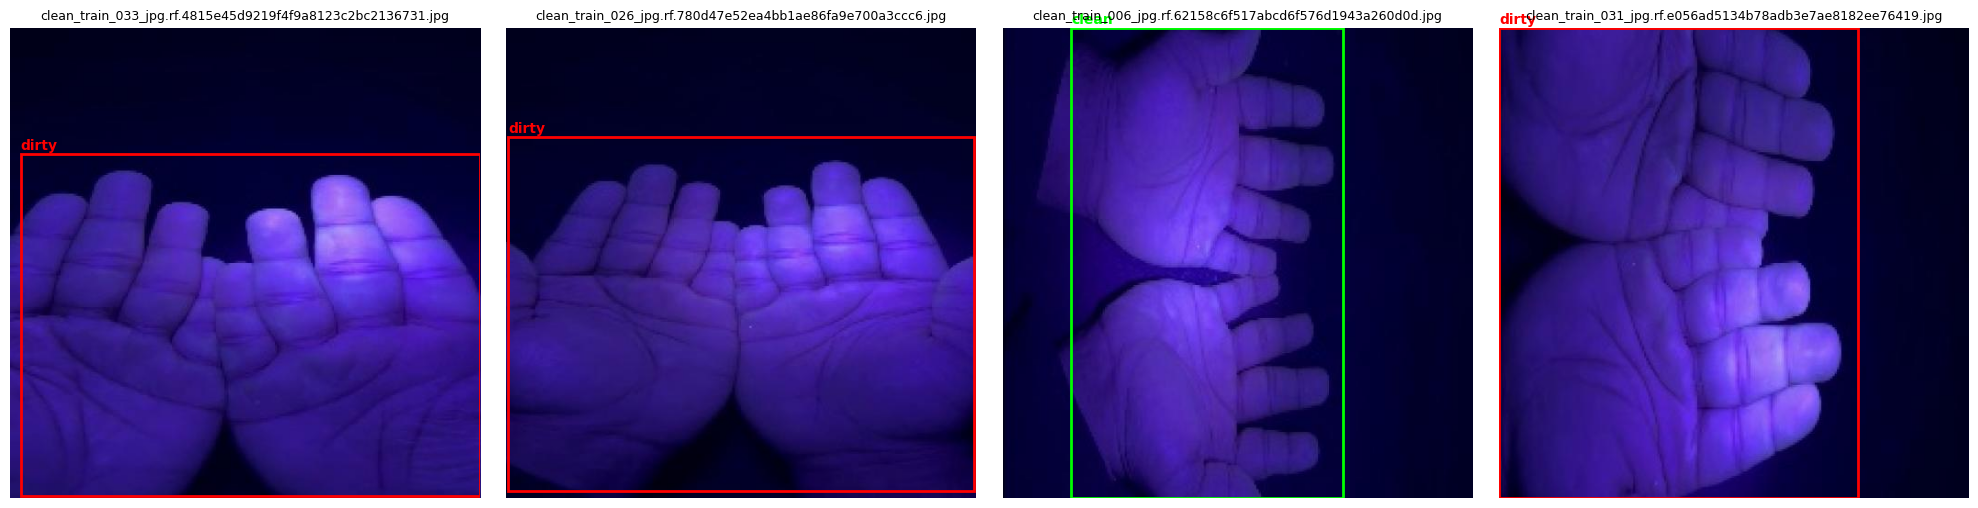

In [16]:
def load_yolo_labels(label_path, img_w, img_h):
    """Parse a YOLO .txt label file into pixel-coordinate boxes."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float, line.strip().split())
            x1 = (x - w / 2) * img_w
            y1 = (y - h / 2) * img_h
            box_w = w * img_w
            box_h = h * img_h
            boxes.append((int(cls), x1, y1, box_w, box_h))
    return boxes

class_names = ["clean", "dirty", "partial"]
colors = ["lime", "red", "orange"]

train_img_dir = os.path.join(dataset_root, "train", "images")
train_lbl_dir = os.path.join(dataset_root, "train", "labels")
sample_images = glob.glob(os.path.join(train_img_dir, "*"))[:4]

if len(sample_images) == 0:
    raise FileNotFoundError(f"No images found in {train_img_dir} — check dataset_root and folder names.")

n = len(sample_images)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_images):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    label_path = os.path.join(train_lbl_dir, Path(img_path).stem + ".txt")
    boxes = load_yolo_labels(label_path, w, h)

    ax.imshow(img)
    for cls, x1, y1, box_w, box_h in boxes:
        rect = patches.Rectangle((x1, y1), box_w, box_h, linewidth=2,
                                  edgecolor=colors[cls], facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, class_names[cls], color=colors[cls], fontsize=10, weight="bold")
    ax.set_title(Path(img_path).name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Load the Base YOLOv8 Model

We start from the pretrained `yolov8m.pt` (medium) checkpoint and fine-tune it on our
hand-hygiene dataset. Using a pretrained checkpoint gives the model a strong head start
compared to training from scratch.


In [17]:
model = YOLO("yolov8m.pt")
print(model.info())


YOLOv8m summary: 169 layers, 25,902,640 parameters, 0 gradients, 79.3 GFLOPs
(169, 25902640, 0, 79.3204224)


## 8. Train the Model

This is the core training step, equivalent to running the following in a terminal:

```bash
yolo detect train model=yolov8m.pt data=data.yaml epochs=50 imgsz=640 batch=16 \
    patience=7 optimizer=AdamW lr0=0.001 weight_decay=0.0005 pretrained=True \
    device=cuda workers=2 project=hand_hygiene name=uv_detection_v1
```

**Parameter explanations:**
- `model` — starting checkpoint (`yolov8m.pt`, the medium-sized YOLOv8 model)
- `data` — path to our `data.yaml` config
- `epochs=50` — number of full passes over the training data
- `imgsz=640` — input image resolution
- `batch=16` — number of images processed per training step
- `patience=7` — stop early if validation performance doesn't improve for 7 epochs
- `optimizer=AdamW` — optimizer used for weight updates
- `lr0=0.001` — initial learning rate
- `weight_decay=0.0005` — L2 regularization to reduce overfitting
- `pretrained=True` — start from pretrained COCO weights
- `device=cuda` — train on GPU (falls back to CPU automatically if unavailable below)
- `workers=2` — number of CPU worker threads for data loading
- `project` / `name` — where results are saved: `hand_hygiene/uv_detection_v1/`


In [18]:
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=7,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    pretrained=True,
    device=device,
    workers=2,
    project=os.path.join(dataset_root, "hand_hygiene"),   # save to Drive, not /content
    name="uv_detection_v1"
)

New https://pypi.org/project/ultralytics/8.4.99 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/HandCleaner.v2i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, moment

## 9. Review Training Results

Ultralytics automatically saves training curves, a confusion matrix, and sample
predictions inside `hand_hygiene/uv_detection_v1/`. Let's load and display the
key results.


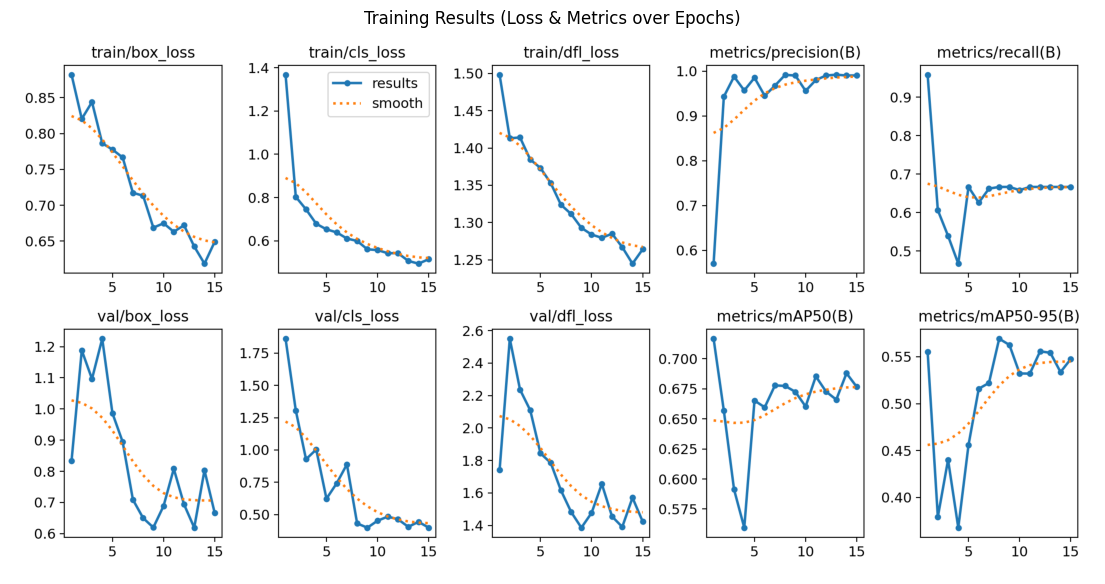

In [19]:
results_dir = os.path.join(dataset_root, "hand_hygiene", "uv_detection_v1")

results_png = os.path.join(results_dir, "results.png")
if os.path.exists(results_png):
    img = cv2.cvtColor(cv2.imread(results_png), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Training Results (Loss & Metrics over Epochs)")
    plt.show()

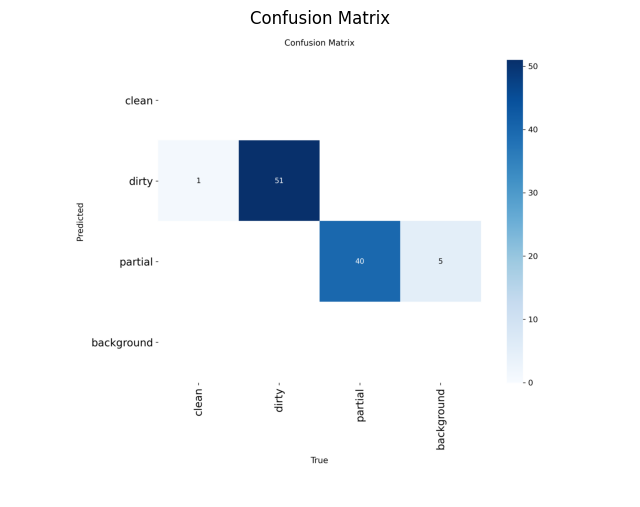

In [20]:
# Confusion matrix
cm_png = os.path.join(results_dir, "confusion_matrix.png")
if os.path.exists(cm_png):
    img = cv2.cvtColor(cv2.imread(cm_png), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix")
    plt.show()


In [21]:
# Read the numeric results CSV for a quick summary table
results_csv = os.path.join(results_dir, "results.csv")
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    display(df.tail(5))


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
10,11,401.876,0.66314,0.54291,1.27950,0.98026,0.66667,0.68529,0.53206,0.80802,0.48443,1.65593,0.000802,0.000802,0.000802
11,12,437.985,0.67210,0.54302,1.28501,0.99041,0.66667,0.67261,0.55578,0.69388,0.46363,1.45535,0.000782,0.000782,0.000782
12,13,475.185,0.64256,0.50729,1.26691,0.99219,0.66667,0.66598,0.55429,0.61892,0.40549,1.39106,0.000762,0.000762,0.000762
13,14,510.763,0.61866,0.49451,1.24481,0.99032,0.66667,0.68788,0.53369,0.80323,0.44362,1.57104,0.000743,0.000743,0.000743
14,15,546.699,0.64912,0.51521,1.26416,0.99060,0.66667,0.67658,0.54760,0.66630,0.39902,1.42367,0.000723,0.000723,0.000723


## 10. Validate the Model

Run formal validation on the `val` split to compute precision, recall, and mAP
(mean Average Precision) — the standard metrics for object detection quality.


In [22]:
best_model_path = os.path.join(results_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

metrics = best_model.val(data=data_yaml_path)   # absolute path here too
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 5.9±11.8 ms, read: 5.6±5.4 MB/s, size: 14.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/HandCleaner.v2i.yolov8/valid/labels.cache... 151 images, 0 backgrounds, 59 corrupt: 100% ━━━━━━━━━━━━ 151/151 57.6Mit/s 0.0s
val: /content/drive/MyDrive/HandCleaner.v2i.yolov8/valid/images/partial_test_000_jpg.rf.fa1477dc807b8022d5e97dfbaf8034fc.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possible class labels are 0-2
val: /content/drive/MyDrive/HandCleaner.v2i.yolov8/valid/images/partial_test_005_jpg.rf.8a3a5f81f2556a8e7fd76a82d14a7aa5.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possi

## 11. Run Inference on Test Images

Let's run the trained model on a few images from the `test` split and visualize the
predicted bounding boxes and class labels.



0: 640x640 4 dirtys, 1 partial, 29.3ms
1: 640x640 1 partial, 29.3ms
2: 640x640 1 partial, 29.3ms
3: 640x640 2 partials, 29.3ms
4: 640x640 2 dirtys, 29.3ms
5: 640x640 2 partials, 29.3ms
Speed: 4.3ms preprocess, 29.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


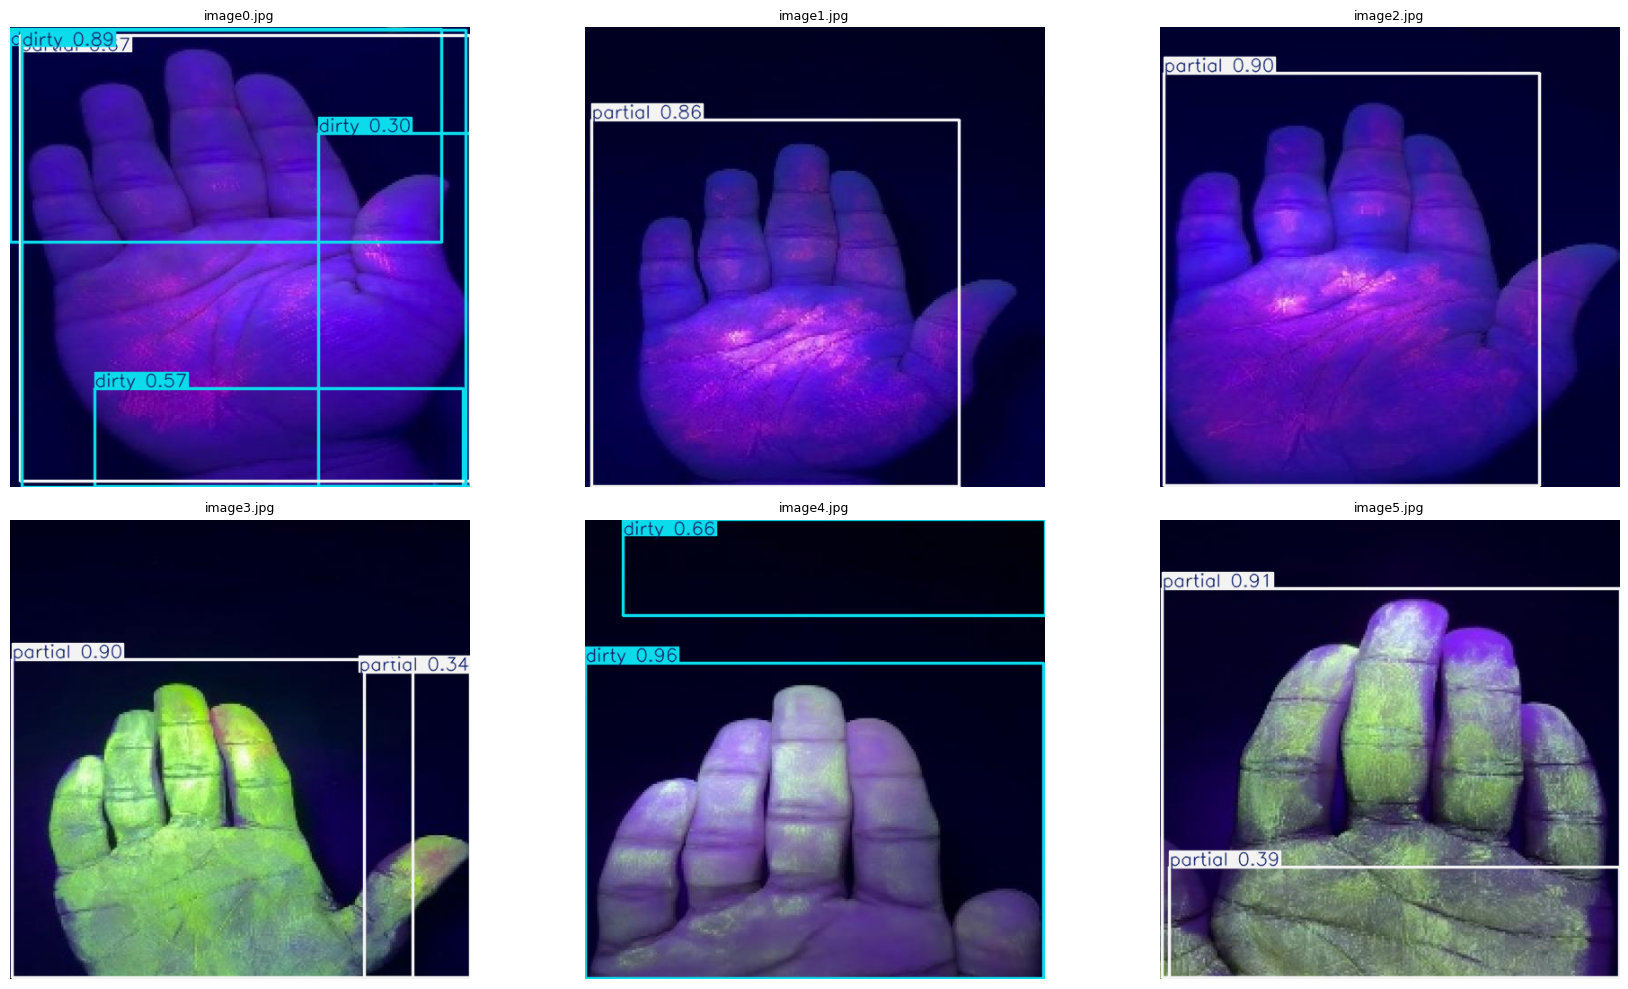

In [23]:
test_img_dir = os.path.join(dataset_root, "test", "images")
test_samples = glob.glob(os.path.join(test_img_dir, "*"))[:6]

predictions = best_model.predict(source=test_samples, conf=0.25, save=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, pred in zip(axes, predictions):
    img = pred.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(Path(pred.path).name, fontsize=9)

plt.tight_layout()
plt.show()

## 12. Export the Final Model

Save the best-performing weights so they can be plugged into the Streamlit app
(or any other deployment target).


In [24]:
import shutil

export_path = os.path.join(dataset_root, "best.pt")
shutil.copy(best_model_path, export_path)
print(f"Best model copied to: {export_path}")

Best model copied to: /content/drive/MyDrive/HandCleaner.v2i.yolov8/best_hand_hygiene_model.pt


## Summary

- Trained a YOLOv8m model on the **hand-hygiene UV dataset** (`clean`, `dirty`, `partial`)
- 50 epochs, AdamW optimizer, early stopping patience of 7
- Validated performance using mAP50, mAP50-95, precision, and recall
- Ran inference on held-out test images
- Exported the best weights (`best_hand_hygiene_model.pt`) for downstream deployment (e.g. the Streamlit frontend)

**Next steps:** experiment with data augmentation, a larger backbone (`yolov8l.pt`), or
longer training if mAP is not yet satisfactory.
